In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax

In [3]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [4]:
import solve
import aux_ as aux
import RANK

## Device

In [5]:
device = aux.choose_gpu()

choosing cpu


## Training the neural network to the DSS and SSS

In [6]:
model = RANK.RANK_model(device)

In [8]:
sigma_quad = {
    "sigma_eps_u" : 0.0082,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}

sigma_sim = { # HIGHER?
    "sigma_eps_u" : 0.0082*2,
    "sigma_eps_z" : 0.0044*2,
    "sigma_eps_Gamma" : 0.0097*2
}

episode_list = [50_000, 2_000_000, 5_000_000, 1_000_000]
lr_list = [1e-4, 1e-4, 5e-5, 1e-6]
N_list = [500, 500, 1000, 1000]
ZLB_list = [-1, 0.00, 0.00, 0.00]
zero_var_list = [None, None, None, None]

In [9]:
solve.train_nn(model, episode_list, sigma_sim, sigma_quad, ZLB_list, lr_list, N_list, zero_var_list, print_freq=100)

-------------------------------------------------- PHASE 0:  --------------------------------------------------
###### sigma_sim = 0.0164, sigma_quad = 0.0082, ZLB = -1, lr = 0.0001, N = 500 ######

Episode 0:	Loss = 0.01170223	Best Loss = 0.01170223		SSS: Y = 0.996, pi = 0.108		ee = 0.07470647	nkpce = 0.05943519	ZLB share = 0.000
Episode 100:	Loss = 0.00114850	Best Loss = 0.00114850		SSS: Y = 0.934, pi = 0.013		ee = 0.02020163	nkpce = 0.01827511	ZLB share = 0.053
Episode 200:	Loss = 0.00068322	Best Loss = 0.00068322		SSS: Y = 0.936, pi = 0.010		ee = 0.01314421	nkpce = 0.01633295	ZLB share = 0.032
Episode 300:	Loss = 0.00039659	Best Loss = 0.00039659		SSS: Y = 0.938, pi = 0.008		ee = 0.00767765	nkpce = 0.01393277	ZLB share = 0.177
Episode 400:	Loss = 0.00022798	Best Loss = 0.00022798		SSS: Y = 0.940, pi = 0.007		ee = 0.00449483	nkpce = 0.01114942	ZLB share = 0.247
Episode 500:	Loss = 0.00012381	Best Loss = 0.00012381		SSS: Y = 0.942, pi = 0.005		ee = 0.00296788	nkpce = 0.00828463	ZLB s

KeyboardInterrupt: 

# Training plots

In [25]:
train_losses = model.info['train_losses']
test_losses = model.info['test_losses']

In [27]:
ee_test_losses = model.info["ee_test_losses"]
nkpce_test_losses = model.info["nkpce_test_losses"]

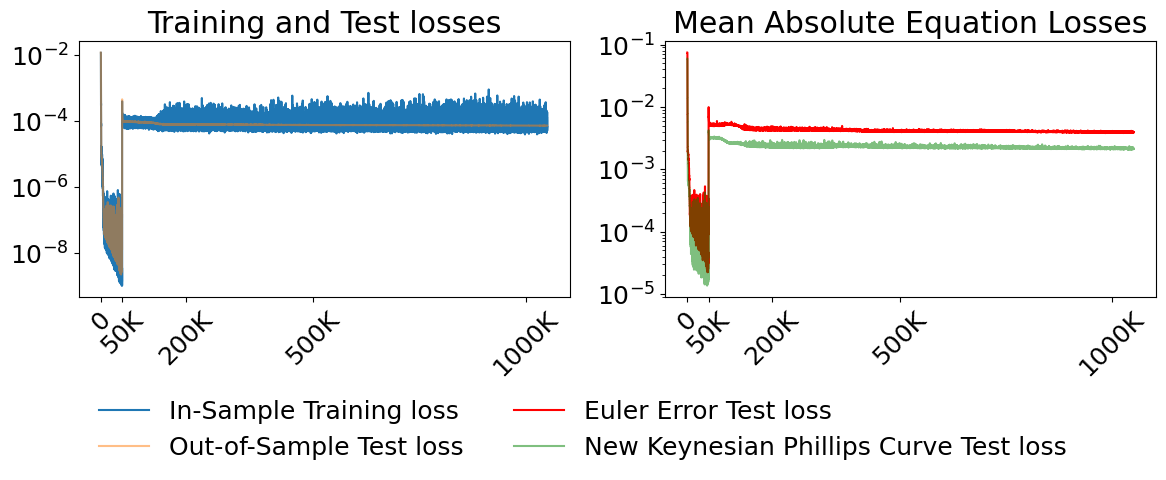

In [64]:
import matplotlib.pyplot as plt

# Opdater skrifttype
plt.rcParams.update({'font.size': 18})

f, ax = plt.subplots(1,2, figsize=(12,5))

# Definitioner
ticks = [0, 50_000, 200_000, 500_000, 1_000_000]
labels = ['0', '50K', '200K', '500K', '1000K']

# --- Plot 1 ---
ax[0].plot(range(len(train_losses)), train_losses, label="In-Sample Training loss")
ax[0].plot(range(len(train_losses)), test_losses, alpha=0.5, label="Out-of-Sample Test loss")
ax[0].set_yscale('log')
ax[0].set_title("Training and Test losses")

# Sæt ticks, labels og rotation
ax[0].set_xticks(ticks)
ax[0].set_xticklabels(labels, rotation=45)

# --- Plot 2 ---
ax[1].plot(range(len(train_losses)), ee_test_losses, label="Euler Error Test loss", color='red')
ax[1].plot(range(len(train_losses)), nkpce_test_losses, label="New Keynesian Phillips Curve Test loss", color='green', alpha=0.5)
ax[1].set_yscale('log')
ax[1].set_title("Mean Absolute Equation Losses")

# Sæt ticks, labels og rotation
ax[1].set_xticks(ticks)
ax[1].set_xticklabels(labels, rotation=45)

# Justering af layout for at give plads til de roterede labels og legenden
f.tight_layout(rect=[0, 0.15, 1, 1])

# Placer legenden centralt i bunden
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, -0.00), 
         ncol=2,          
         frameon=False)

f.savefig('plots/test_train_losses.png')